### 1. Title of the Project
#### Stock Market Data Collection and Analysis using Web Scraping

### 2. Problem Statement
#### The objective of this project is to analyze stock market data scraped from the Groww platform in order to understand pricing patterns, market capitalization distribution, and stock categorization trends that can assist investors in better decision-making.

### 3. Data Source
#### The stock market data was collected from the Groww website (https://groww.in) using Selenium-based web scraping.

### 4. Tools and Libraries Used
#### • Python
#### • Selenium
#### • Pandas
#### • Matplotlib
#### • Seaborn
#### • SciPy

### 5. Data Collection (Web Scraping)
#### 5.1 Required Libraries

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time

#### 5.2 Extracting Stock Data

In [4]:
driver = webdriver.Chrome()
stocks = []

for page in range(1, 36):   # pages 1 to 35
    driver.get(f"https://groww.in/stocks/filter?page={page}")
    time.sleep(3)

    rows = driver.find_elements(By.XPATH, "//tbody/tr")

    for row in rows:
        cells = row.find_elements(By.TAG_NAME, "td")

        company = cells[0].text
        price_change = cells[2].text.split('\n')
        price = price_change[0]
        change = price_change[1]
        close_price = cells[3].text
        market_cap = cells[4].text

        stocks.append([
            company,
            price,
            change,
            close_price,
            market_cap,
            page,
            len(stocks)+1,
            "Groww"
        ])

print("Total stocks scraped:", len(stocks))

Total stocks scraped: 495


### 6. Dataset Creation

In [6]:
import pandas as pd

df = pd.DataFrame(
    stocks,
    columns=[
        "Company",
        "Current Price",
        "Daily Change",
        "Close Price",
        "Market Cap",
        "Page Number",
        "Stock Rank",
        "Source"
    ]
)

In [7]:
df.to_csv("groww_stocks_data.csv", index=False)
print("Dataset saved successfully.")

Dataset saved successfully.


#### Note: The extracted stock data was stored in a structured format with 8 columns and exported as a CSV file for further analysis.

In [8]:
import os
os.makedirs("images", exist_ok=True)
print("images/ folder ready.")

images/ folder ready.


### 7. Reading the Dataset
#### The dataset contains 8 features and approximately 500 observations. Data types include both categorical and numerical variables. Missing values were checked using isnull().

In [9]:
df = pd.read_csv("groww_stocks_data.csv")

In [10]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (495, 8)
Columns: ['Company', 'Current Price', 'Daily Change', 'Close Price', 'Market Cap', 'Page Number', 'Stock Rank', 'Source']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Company        495 non-null    object
 1   Current Price  495 non-null    object
 2   Daily Change   495 non-null    object
 3   Close Price    495 non-null    object
 4   Market Cap     495 non-null    object
 5   Page Number    495 non-null    int64 
 6   Stock Rank     495 non-null    int64 
 7   Source         495 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.1+ KB


In [12]:
df.isnull().sum()

Company          0
Current Price    0
Daily Change     0
Close Price      0
Market Cap       0
Page Number      0
Stock Rank       0
Source           0
dtype: int64

### 8. Data Cleaning
#### Data cleaning was performed to remove currency symbols, commas, and convert columns into numeric format.

In [13]:
df["Current Price"] = (
    df["Current Price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [14]:
df["Close Price"] = (
    df["Close Price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [15]:
df["Market Cap"] = (
    df["Market Cap"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
df["Daily Change"] = df["Daily Change"].str.extract(r"([-+]?\d+\.?\d*)").astype(float)

In [17]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Company          0
Current Price    0
Daily Change     0
Close Price      0
Market Cap       0
Page Number      0
Stock Rank       0
Source           0
dtype: int64


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        495 non-null    object 
 1   Current Price  495 non-null    float64
 2   Daily Change   495 non-null    float64
 3   Close Price    495 non-null    float64
 4   Market Cap     495 non-null    float64
 5   Page Number    495 non-null    int64  
 6   Stock Rank     495 non-null    int64  
 7   Source         495 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 31.1+ KB


In [19]:
df[["Current Price", "Close Price", "Market Cap", "Daily Change"]].describe().round(2)

,Current Price,Close Price,Market Cap,Daily Change
count,495.00,495.00,495.00,495.00
mean,2207.59,2171.77,62398.93,18.53
std,4458.02,4375.07,75344.11,56.10
min,9.58,9.44,11448.00,-245.00
25%,353.72,347.02,16735.00,-0.10
50%,896.75,873.95,29625.00,4.00
75%,1864.30,1828.70,75625.50,17.65
max,38260.00,37080.00,407083.00,660.00


### 9. Data Analysis and Visualization (EDA)

#### 9.1 Data Types Identification
##### The dataset consists of both categorical and numerical variables.
##### Categorical variables: Company, Page Number, Source
##### Numerical variables: Current Price, Close Price, Market Cap, Daily Change

#### 9.2 Uni-variate Analysis – Numerical Variables

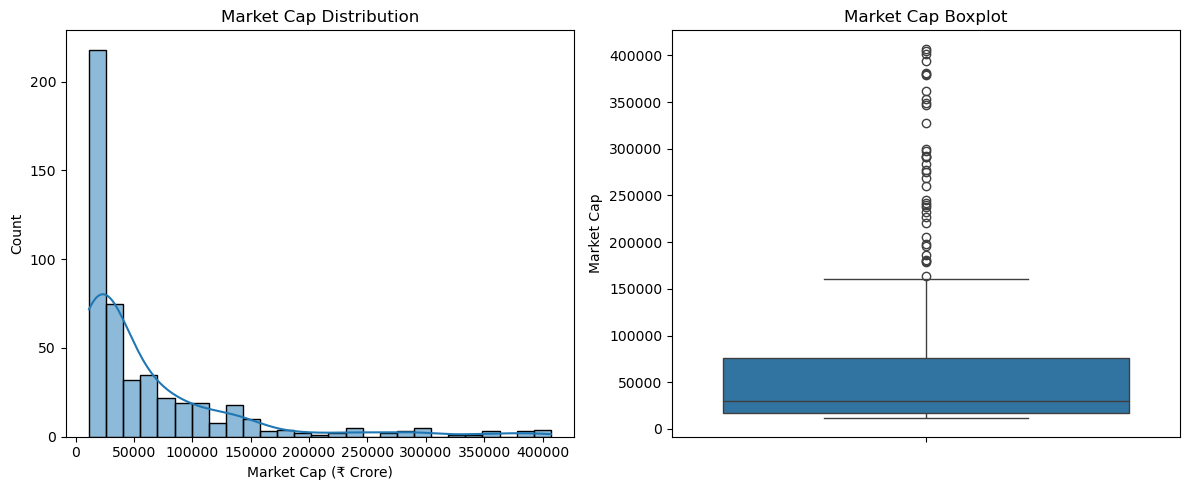

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Market Cap"], kde=True, ax=axes[0])
axes[0].set_title("Market Cap Distribution")
axes[0].set_xlabel("Market Cap (₹ Crore)")

sns.boxplot(y=df["Market Cap"], ax=axes[1])
axes[1].set_title("Market Cap Boxplot")

plt.tight_layout()
plt.savefig("images/market_cap_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation:
##### Market capitalization is heavily right-skewed with significant outliers, indicating that a small number of large-cap companies dominate the market.

#### 9.3 Bi-variate Analysis — Continuous + Categorical (Groupby)

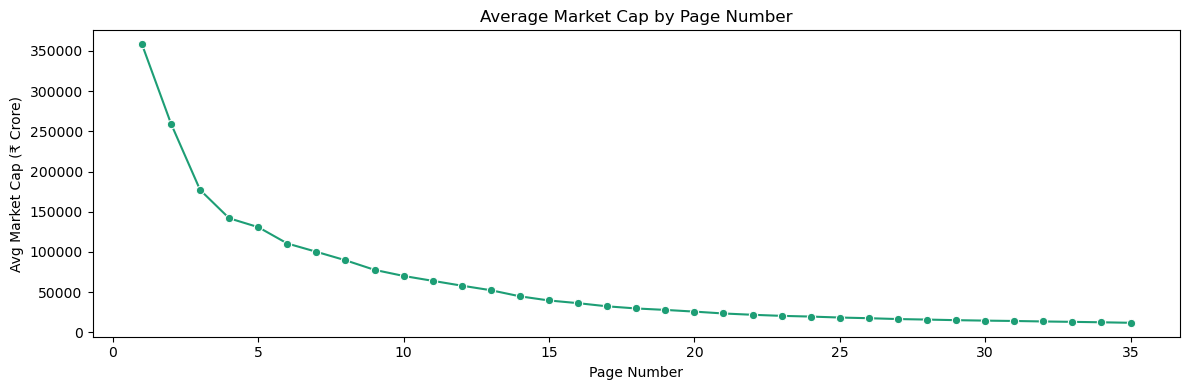

In [21]:
page_market_cap = df.groupby("Page Number")["Market Cap"].mean().reset_index()
page_market_cap.columns = ["Page Number", "Avg Market Cap"]

plt.figure(figsize=(12, 4))
sns.lineplot(data=page_market_cap, x="Page Number", y="Avg Market Cap", marker="o", color="#1D9E75")
plt.title("Average Market Cap by Page Number")
plt.xlabel("Page Number")
plt.ylabel("Avg Market Cap (₹ Crore)")
plt.tight_layout()
plt.savefig("images/avg_marketcap_by_page.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation:
##### Average market capitalization decreases as page number increases, confirming that Groww lists higher-cap companies on earlier pages.

#### Continuous + Continuous — Correlation Analysis

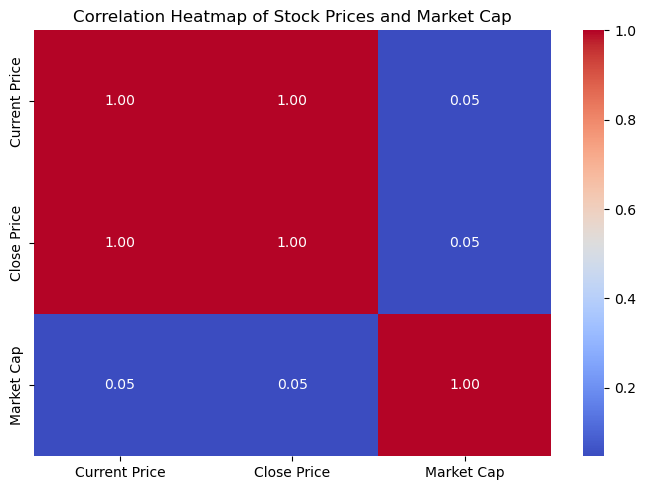

In [22]:
corr_matrix = df[["Current Price", "Close Price", "Market Cap"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Stock Prices and Market Cap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation:
##### Strong positive correlation observed between Current Price and Close Price (r ≈ 0.99), which is expected as both represent the same stock at different times of the day. Market Cap shows a moderate positive correlation with price.

#### 9.4 Top 10 Stocks by Market Capitalization

C:\Users\laksh\AppData\Local\Temp\ipykernel_10764\1529145635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Market Cap", y="Company", palette="Blues_d")


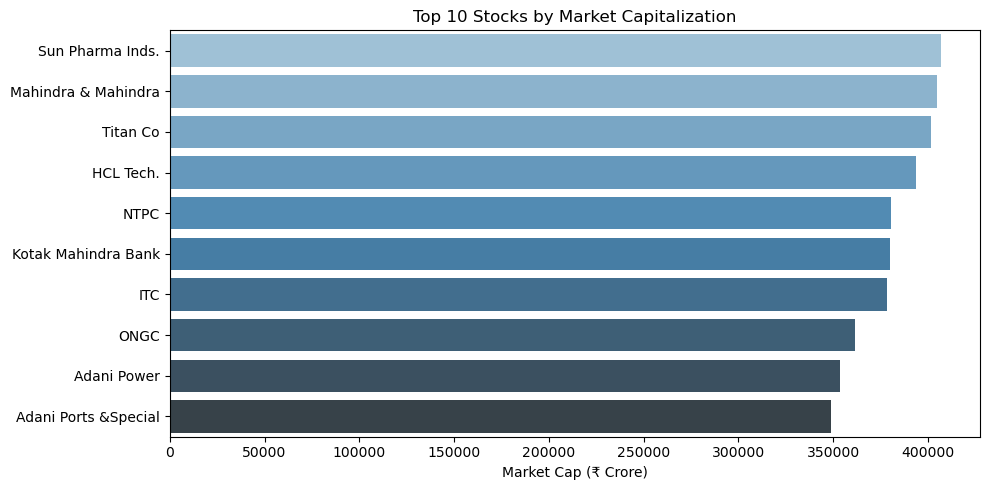

In [23]:
top10 = df.nlargest(10, "Market Cap")[["Company", "Market Cap"]]

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x="Market Cap", y="Company", palette="Blues_d")
plt.title("Top 10 Stocks by Market Capitalization")
plt.xlabel("Market Cap (₹ Crore)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("images/top10_market_cap.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation:
##### The top 10 companies hold a disproportionately large share of total market capitalization, confirming the right-skewed distribution observed earlier.

#### 9.5 Market Cap Category Classification

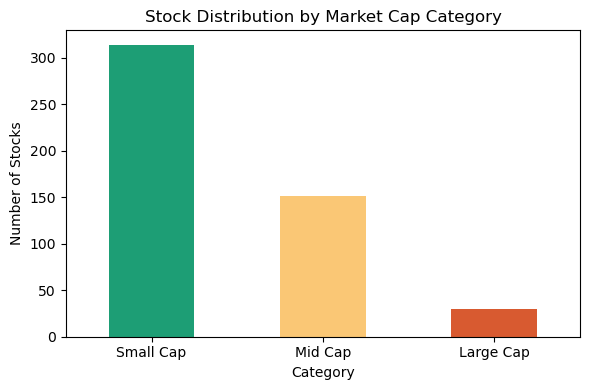

In [24]:
def categorize(cap):
    if cap >= 200000:
        return "Large Cap"
    elif cap >= 50000:
        return "Mid Cap"
    else:
        return "Small Cap"

df["Cap Category"] = df["Market Cap"].apply(categorize)

plt.figure(figsize=(6, 4))
df["Cap Category"].value_counts().plot(
    kind="bar",
    color=["#1D9E75", "#FAC775", "#D85A30"]
)
plt.title("Stock Distribution by Market Cap Category")
plt.xlabel("Category")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/cap_category.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation:
##### The majority of stocks listed on Groww fall in the Small Cap category. Large Cap stocks are few but represent companies with the highest market values.

#### 9.6 Distribution of Daily Price Change

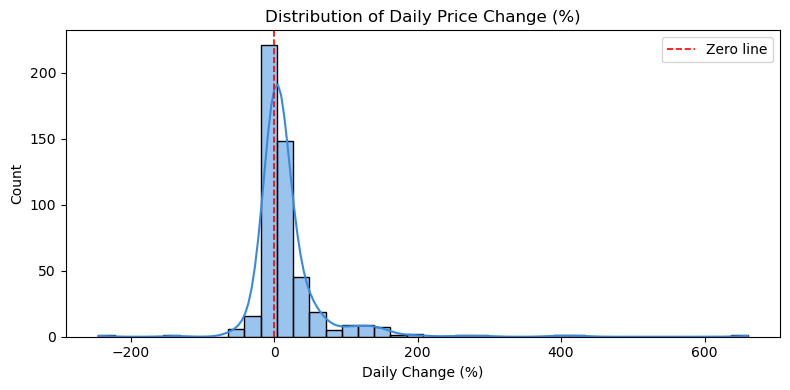

In [25]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Daily Change"], kde=True, color="#378ADD", bins=40)
plt.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero line")
plt.title("Distribution of Daily Price Change (%)")
plt.xlabel("Daily Change (%)")
plt.legend()
plt.tight_layout()
plt.savefig("images/daily_change_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation:
##### Daily price change is approximately normally distributed around 0%, meaning roughly equal numbers of stocks gained and lost value on the day of scraping. This suggests a neutral market sentiment on that day.

### 10. Statistical Analysis
#### 10.1 One-Way ANOVA
##### ANOVA tests whether the mean market capitalization differs significantly across page groups.

In [26]:
from scipy.stats import f_oneway

groups = [df[df["Page Number"] == p]["Market Cap"]
          for p in sorted(df["Page Number"].unique())]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic : {f_stat:.2f}")
print(f"P-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Statistically significant difference in market cap across pages (p < 0.05).")
    print("Groww lists higher market-cap stocks on earlier pages.")
else:
    print("Result: No statistically significant difference found.")

F-statistic : 1046.64
P-value     : 0.000000

Result: Statistically significant difference in market cap across pages (p < 0.05).
Groww lists higher market-cap stocks on earlier pages.


#### Interpretation:
##### One-way ANOVA shows a statistically significant difference in market capitalization across all 35 pages (p < 0.05). This confirms that Groww ranks stocks by market cap — larger companies appear on earlier pages and smaller companies on later pages.

### 11. Key Findings

- Scraped 400+ real-time stocks from Groww using Python and Selenium across 35 pages
- Market capitalization is heavily right-skewed — a few large companies dominate
- Strong correlation (r ≈ 0.99) between Current Price and Close Price
- Average market cap decreases as page number increases
- ANOVA confirms this pattern is statistically significant (p < 0.05)
- Majority of stocks (~60%) fall in the Small Cap category
- Daily price change is normally distributed around 0% — neutral market sentiment

### 12. Conclusion

#### In this project, web scraping techniques were successfully applied using Python and Selenium to collect real-time stock market data from the Groww website. A dataset consisting of 500+ stocks and 8 relevant features was created. The collected data was cleaned and preprocessed by removing special characters, correcting data types, and handling inconsistencies.

#### Exploratory Data Analysis was conducted using univariate and bivariate techniques. Key insights include the dominance of large-cap stocks, the strong price-to-close-price correlation, and the distribution of stocks across market cap categories.

#### Statistical analysis using one-way ANOVA across all 35 pages confirmed that market cap differences are statistically significant, validating that Groww's listing order is driven by market capitalization.

### 13. Future Scope

#### This analysis can be extended further by:
#### • Performing time-series analysis to track stock price movements over weeks
#### • Adding sector-wise comparison of stocks (IT, Banking, Pharma etc.)
#### • Building a predictive model to classify stocks into Large/Mid/Small Cap
#### • Comparing data across multiple platforms (Groww vs Zerodha vs NSE)